# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import pandas as pd
from IPython.display import display

from music_recsys import (
    DEFAULT_CANDIDATE_K,
    DEFAULT_TOP_K,
    RANKER_VALID_CUTOFF,
    S3Config,
    TRAIN_CUTOFF,
    build_items,
    get_top_genres,
    get_top_tracks,
    get_unheard_tracks,
    inspect_raw_data,
    load_raw_data,
    metrics_to_frame,
    plot_user_listen_distribution,
    run_offline_pipeline_from_files,
    save_stage2_outputs,
)

BASE_DIR = Path(".")
S3_CONFIG = S3Config.from_env()
TOP_K = DEFAULT_TOP_K
CANDIDATE_K = DEFAULT_CANDIDATE_K

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks, catalog_names, interactions = load_raw_data(BASE_DIR)

print(f"tracks: {tracks.shape}")
print(f"catalog_names: {catalog_names.shape}")
print(f"interactions: {interactions.shape}")

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


In [3]:
display(tracks.head(3))
display(catalog_names.head(3))
display(interactions.head(3))

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [4]:
raw_summary, raw_details = inspect_raw_data(tracks, catalog_names, interactions)

display(raw_summary)
display(pd.Series(raw_details, name="value").to_frame())

,table,rows,unique_track_id,date_min,date_max
0,tracks,1000000,1000000,NaT,NaT
1,catalog_names,1812471,<NA>,NaT,NaT
2,interactions,222629898,1000000,2022-01-01,2022-12-31


,value
track_id_dtype,int64
catalog_id_dtype,int64
user_id_dtype,int32
track_seq_dtype,int16
started_at_dtype,datetime64[ns]
track_name_missing,0
empty_albums,18
empty_artists,15369
empty_genres,3687
non_positive_track_seq,0


In [5]:
items, missing_genres = build_items(tracks, catalog_names)

display(items.head(3))
print(f"Отсутствующих жанровых id в catalog_names: {len(missing_genres)}")
print(f"Примеры отсутствующих id: {missing_genres[:10]}")

,track_id,track_name,albums,artists,genres,album_names,artist_names,genre_names,album_count,artist_count,genre_count
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]","[Taller Children, Taller Children]",[Elizabeth & the Catapult],"[pop, folk]",2,1,2
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]","[Taller Children, Taller Children]",[Elizabeth & the Catapult],"[pop, folk]",2,1,2
2,135,Atticus,"[12, 214, 2490809]",[84],[11],"[Wild Young Hearts, Wild Young Hearts, Wild Young Hearts]",[Noisettes],[pop],3,1,1


Отсутствующих жанровых id в catalog_names: 30
Примеры отсутствующих id: [124, 126, 130, 131, 132, 133, 134, 135, 146, 148]


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

In [6]:
stage1_conclusions = [
    f"1. Типы идентификаторов уже корректны: track_id={raw_details['track_id_dtype']}, catalog id={raw_details['catalog_id_dtype']}, user_id={raw_details['user_id_dtype']}.",
    f"2. По артистам и альбомам пропусков в справочнике нет; по жанрам обнаружено {raw_details['unknown_genres_ids']} отсутствующих id.",
    f"3. Чтобы не терять треки, для отсутствующих жанров в items добавлены технические названия unknown_genre_<id>.",
    f"4. Пустые списки в метаданных встречаются, но это не ломает пайплайн: empty_artists={raw_details['empty_artists']}, empty_genres={raw_details['empty_genres']}.",
    f"5. Во взаимодействиях не найдено некорректных дат, а track_seq <= 0 встречается {raw_details['non_positive_track_seq']} раз."
]

print("\n".join(stage1_conclusions))

1. Типы идентификаторов уже корректны: track_id=int64, catalog id=int64, user_id=int32.
2. По артистам и альбомам пропусков в справочнике нет; по жанрам обнаружено 30 отсутствующих id.
3. Чтобы не терять треки, для отсутствующих жанров в items добавлены технические названия unknown_genre_<id>.
4. Пустые списки в метаданных встречаются, но это не ломает пайплайн: empty_artists=15369, empty_genres=3687.
5. Во взаимодействиях не найдено некорректных дат, а track_seq <= 0 встречается 0 раз.


In [7]:
stage1_quality_table = pd.DataFrame(
    {
        "metric": [
            "users in interactions",
            "tracks in interactions",
            "empty albums",
            "empty artists",
            "empty genres",
            "missing genre ids",
        ],
        "value": [
            raw_details["user_count"],
            raw_details["track_count_in_events"],
            raw_details["empty_albums"],
            raw_details["empty_artists"],
            raw_details["empty_genres"],
            raw_details["unknown_genres_ids"],
        ],
    }
)

display(stage1_quality_table)

,metric,value
0,users in interactions,1373221
1,tracks in interactions,1000000
2,empty albums,18
3,empty artists,15369
4,empty genres,3687
5,missing genre ids,30


# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

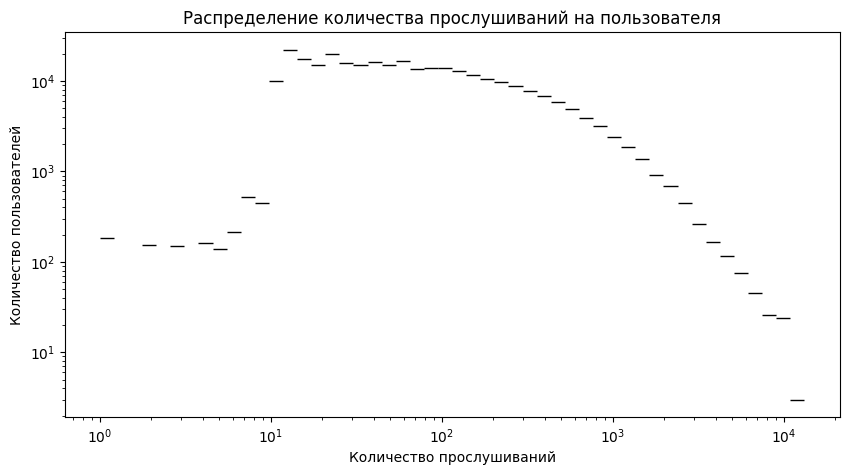

,count,mean,std,min,50%,90%,95%,99%,max
listen_count,1373221.0,162.12241,351.284625,1.0,55.0,389.0,650.0,1576.0,16637.0


In [8]:
user_listen_distribution = plot_user_listen_distribution(interactions)
display(user_listen_distribution["listen_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame(name="listen_count").T)

Наиболее популярные треки

In [9]:
top_tracks = get_top_tracks(interactions, items, top_n=20)
display(top_tracks)

,track_id,listen_count,track_name,artist_names,genre_names
0,53404,111062,Smells Like Teen Spirit,[Nirvana],"[alternative, rock, allrock]"
1,33311009,106921,Believer,[Imagine Dragons],"[rock, allrock]"
2,178529,101924,Numb,[Linkin Park],"[numetal, metal]"
3,35505245,99490,I Got Love,"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]"
4,65851540,86670,Юность,[Dabro],"[pop, ruspop]"
5,24692821,86246,Way Down We Go,[KALEO],[indie]
6,32947997,85886,Shape of You,[Ed Sheeran],[pop]
7,51241318,85244,In The End,"[Tommee Profitt, Fleurie, Mellen Gi]",[rnb]
8,795836,85042,Shape Of My Heart,[Sting],"[pop, rock, allrock]"
9,45499814,84748,Life,[Zivert],"[pop, ruspop]"


Наиболее популярные жанры

In [10]:
top_genres = get_top_genres(interactions, items, top_n=20)
display(top_genres)

,genre_names,listen_count
0,pop,55578312
3,rap,37799821
11,allrock,31092013
1,ruspop,26626241
2,rusrap,25303695
8,electronics,20120981
7,dance,16291557
18,rusrock,13166147
23,rock,12772644
12,metal,12437375


Треки, которые никто не прослушал

In [11]:
unheard_track_count, unheard_tracks = get_unheard_tracks(interactions, items, sample_size=20)
print(f"Треков, которые никто не прослушал: {unheard_track_count}")
display(unheard_tracks)

Треков, которые никто не прослушал: 0


,track_id,track_name,artist_names


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [12]:
events = interactions

print(f"items: {items.shape}")
print(f"events: {events.shape}")
display(items.head(3))
display(events.head(3))

items: (1000000, 11)
events: (222629898, 4)


,track_id,track_name,albums,artists,genres,album_names,artist_names,genre_names,album_count,artist_count,genre_count
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]","[Taller Children, Taller Children]",[Elizabeth & the Catapult],"[pop, folk]",2,1,2
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]","[Taller Children, Taller Children]",[Elizabeth & the Catapult],"[pop, folk]",2,1,2
2,135,Atticus,"[12, 214, 2490809]",[84],[11],"[Wild Young Hearts, Wild Young Hearts, Wild Young Hearts]",[Noisettes],[pop],3,1,1


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [13]:
stage2_paths = save_stage2_outputs(items, events, BASE_DIR, S3_CONFIG)
display(pd.Series(stage2_paths, name="path_or_uri").to_frame())

if not S3_CONFIG.enabled:
    print("S3 не настроен в окружении, поэтому на этом запуске файлы сохранены только локально.")

,path_or_uri
items_local,items.parquet
events_local,events.parquet
items_s3,None
events_s3,None


S3 не настроен в окружении, поэтому на этом запуске файлы сохранены только локально.


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [14]:
del tracks, catalog_names, interactions
print("Исходные tracks, catalog_names и interactions удалены из лишних ссылок; для этапа 3 остаются items и events.")

Исходные tracks, catalog_names и interactions удалены из лишних ссылок; для этапа 3 остаются items и events.


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [15]:
if "items" not in globals():
    items = pd.read_parquet(BASE_DIR / "items.parquet")

if "events" not in globals():
    events = pd.read_parquet(BASE_DIR / "events.parquet")

In [16]:
print(f"items: {items.shape}")
print(f"events: {events.shape}")
display(events.head(3))

items: (1000000, 11)
events: (222629898, 4)


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [17]:
events_train = events.loc[events["started_at"] < TRAIN_CUTOFF, ["user_id", "track_id"]]
events_test = events.loc[events["started_at"] >= TRAIN_CUTOFF, ["user_id", "track_id"]]
events_fit = events.loc[events["started_at"] < RANKER_VALID_CUTOFF, ["user_id", "track_id"]]
events_label = events.loc[
    (events["started_at"] >= RANKER_VALID_CUTOFF) & (events["started_at"] < TRAIN_CUTOFF),
    ["user_id", "track_id"],
]

In [18]:
split_summary = pd.DataFrame(
    [
        {"split": "ranker fit (< 2022-12-09)", "rows": len(events_fit), "users": events_fit["user_id"].nunique()},
        {"split": "ranker labels (2022-12-09 .. 2022-12-15)", "rows": len(events_label), "users": events_label["user_id"].nunique()},
        {"split": "train (< 2022-12-16)", "rows": len(events_train), "users": events_train["user_id"].nunique()},
        {"split": "test (>= 2022-12-16)", "rows": len(events_test), "users": events_test["user_id"].nunique()},
    ]
)

display(split_summary)
print(f"Метрики считаю на top-{TOP_K}, а для генерации кандидатов использую top-{CANDIDATE_K}.")

,split,rows,users
0,ranker fit (< 2022-12-09),200834917,1321308
1,ranker labels (2022-12-09 .. 2022-12-15),7896335,744050
2,train (< 2022-12-16),208731252,1342566
3,test (>= 2022-12-16),13898646,783525


Метрики считаю на top-5, а для генерации кандидатов использую top-5.


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [19]:
if "events" in globals():
    del events

offline_result = run_offline_pipeline_from_files(
    BASE_DIR / "items.parquet",
    BASE_DIR / "events.parquet",
    BASE_DIR,
    S3_CONFIG,
    top_k=TOP_K,
    candidate_k=CANDIDATE_K,
)

top_popular_recs = offline_result["top_popular"]
personal_als_recs = offline_result["personal_als"]
similar_tracks = offline_result["similar"]
final_recommendations = offline_result["recommendations"]
metrics_frame = metrics_to_frame(offline_result["metrics"])

display(pd.Series(offline_result["saved_paths"], name="path_or_uri").to_frame())

,path_or_uri
top_popular_local,top_popular.parquet
personal_als_local,personal_als.parquet
similar_local,similar.parquet
recommendations_local,recommendations.parquet
metrics_local,metrics.json


In [20]:
top_popular_preview = top_popular_recs.merge(
    items[["track_id", "track_name", "artist_names"]],
    on="track_id",
    how="left",
)

display(top_popular_preview.head(20))

,user_id,track_id,score,rank,track_name,artist_names
0,3,53404,11.608481,1,Smells Like Teen Spirit,[Nirvana]
1,3,33311009,11.523638,2,Believer,[Imagine Dragons]
2,3,178529,11.521558,3,Numb,[Linkin Park]
3,3,795836,11.335591,4,Shape Of My Heart,[Sting]
4,3,6705392,11.297365,5,Seven Nation Army,[The White Stripes]
5,4,53404,11.608481,1,Smells Like Teen Spirit,[Nirvana]
6,4,33311009,11.523638,2,Believer,[Imagine Dragons]
7,4,178529,11.521558,3,Numb,[Linkin Park]
8,4,35505245,11.467133,4,I Got Love,"[Miyagi & Эндшпиль, Рем Дигга]"
9,4,24692821,11.340404,5,Way Down We Go,[KALEO]


# Персональные

Рассчитаем персональные рекомендации.

In [21]:
personal_als_preview = personal_als_recs.merge(
    items[["track_id", "track_name", "artist_names"]],
    on="track_id",
    how="left",
)

display(personal_als_preview.head(20))

,user_id,track_id,score,rank,track_name,artist_names
0,3,45499814,0.243262,1,Life,[Zivert]
1,3,44184116,0.207996,2,Незабудка,[Тима Белорусских]
2,3,54798445,0.204901,3,Прятки,[HammAli & Navai]
3,3,39946957,0.199848,4,Зелёные волны,[Zivert]
4,3,57921154,0.187814,5,Комета,[JONY]
5,4,6705392,0.165909,1,Seven Nation Army,[The White Stripes]
6,4,694683,0.160995,2,Highway to Hell,[AC/DC]
7,4,1710810,0.159952,3,Another One Bites The Dust,[Queen]
8,4,679169,0.140496,4,Thunderstruck,[AC/DC]
9,4,2280250,0.134832,5,Pumped Up Kicks,[Foster The People]


In [22]:
display(personal_als_recs.groupby("user_id").size().describe().to_frame(name="personal_als_per_user").T)

,count,mean,std,min,25%,50%,75%,max
personal_als_per_user,752870.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [23]:
similar_preview = (
    similar_tracks.head(20)
    .merge(items[["track_id", "track_name"]], on="track_id", how="left")
    .merge(
        items[["track_id", "track_name"]].rename(
            columns={"track_id": "similar_track_id", "track_name": "similar_track_name"}
        ),
        on="similar_track_id",
        how="left",
    )
)

display(similar_preview)

,track_id,similar_track_id,score,rank,track_name,similar_track_name
0,26,29854999,0.883284,1,Complimentary Me,Jogi
1,26,27419607,0.876755,2,Complimentary Me,"Пой, Вася"
2,26,19812170,0.875444,3,Complimentary Me,Море
3,26,24526436,0.874692,4,Complimentary Me,Подойди поближе
4,26,21644998,0.873826,5,Complimentary Me,Ворон
5,38,31200552,0.875486,1,Momma's Boy,The River (Dubstep)
6,38,29846962,0.874642,2,Momma's Boy,Party Raiser
7,38,27121940,0.857046,3,Momma's Boy,Unholy Roller
8,38,31655014,0.855617,4,Momma's Boy,Leave Me
9,38,32054405,0.852514,5,Momma's Boy,Herren der Winde


In [24]:
display(similar_tracks.groupby("track_id").size().describe().to_frame(name="similar_per_track").T)

,count,mean,std,min,25%,50%,75%,max
similar_per_track,1000000.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [25]:
ranker_features = pd.DataFrame(
    [
        {"feature": "als_score", "description": "оценка кандидата от ALS"},
        {"feature": "als_rank", "description": "позиция кандидата в выдаче ALS"},
        {"feature": "track_popularity_log", "description": "логарифм глобальной популярности трека в train"},
        {"feature": "source_count", "description": "число источников кандидата (в текущей конфигурации равно 1)"},
        {"feature": "user_history_len", "description": "длина истории пользователя в train"},
        {"feature": "artist_count", "description": "сколько артистов указано у трека"},
        {"feature": "genre_count", "description": "сколько жанров указано у трека"},
        {"feature": "album_count", "description": "сколько альбомов связано с треком"},
    ]
)

display(ranker_features)

,feature,description
0,als_score,оценка кандидата от ALS
1,als_rank,позиция кандидата в выдаче ALS
2,track_popularity_log,логарифм глобальной популярности трека в train
3,source_count,число источников кандидата (в текущей конфигурации равно 1)
4,user_history_len,длина истории пользователя в train
5,artist_count,сколько артистов указано у трека
6,genre_count,сколько жанров указано у трека
7,album_count,сколько альбомов связано с треком


In [26]:
print(
    "Ранжирующая модель обучается на внутреннем временном окне 2022-12-09 .. 2022-12-15, "
    "используя ALS-кандидатов и набор числовых признаков по пользователю и треку. "
    "Затем эта модель применяется к ALS-кандидатам, построенным по train-части до 2022-12-16, "
    "поэтому тестовая выборка не используется при обучении ранжировщика."
)

Ранжирующая модель обучается на внутреннем временном окне 2022-12-09 .. 2022-12-15, используя ALS-кандидатов и набор числовых признаков по пользователю и треку. Затем эта модель применяется к ALS-кандидатам, построенным по train-части до 2022-12-16, поэтому тестовая выборка не используется при обучении ранжировщика.


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [27]:
ranked_preview = final_recommendations.merge(
    items[["track_id", "track_name", "artist_names"]],
    on="track_id",
    how="left",
)

display(ranked_preview.head(20))

,user_id,track_id,score,rank,track_name,artist_names
0,3,54798445,0.023800,1,Прятки,[HammAli & Navai]
1,3,57921154,0.021171,2,Комета,[JONY]
2,3,39946957,0.021053,3,Зелёные волны,[Zivert]
3,3,45499814,0.020227,4,Life,[Zivert]
4,3,44184116,0.017306,5,Незабудка,[Тима Белорусских]
5,4,679169,0.009968,1,Thunderstruck,[AC/DC]
6,4,6705392,0.007405,2,Seven Nation Army,[The White Stripes]
7,4,694683,0.005673,3,Highway to Hell,[AC/DC]
8,4,2280250,0.005123,4,Pumped Up Kicks,[Foster The People]
9,4,1710810,0.004688,5,Another One Bites The Dust,[Queen]


In [28]:
display(final_recommendations.groupby("user_id").size().describe().to_frame(name="ranked_recs_per_user").T)

,count,mean,std,min,25%,50%,75%,max
ranked_recs_per_user,752870.0,5.0,0.0,5.0,5.0,5.0,5.0,5.0


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [29]:
display(metrics_frame)

,model,precision,recall,coverage,novelty
0,top_popular,0.004024,0.001395,0.000083,3.796820
1,personal_als,0.011555,0.007929,0.001619,4.722115
2,ranked,0.011555,0.007929,0.001619,4.722115


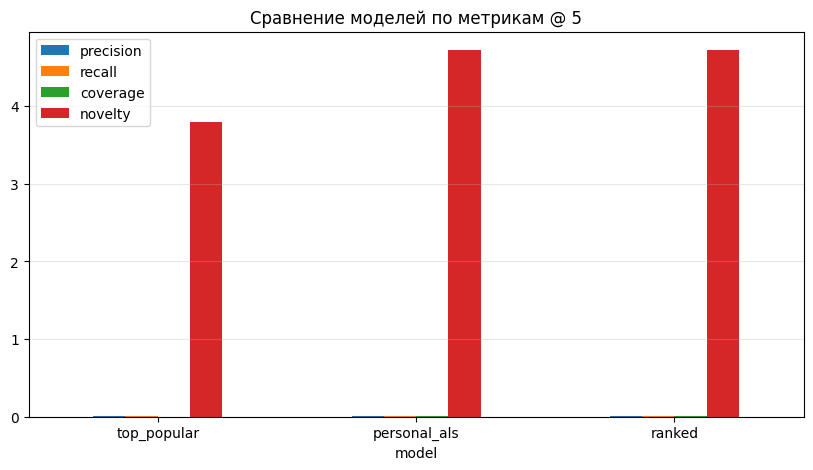

In [30]:
ax = metrics_frame.set_index("model")[["precision", "recall", "coverage", "novelty"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
    title=f"Сравнение моделей по метрикам @ {TOP_K}",
)
ax.set_xlabel("model")
ax.grid(axis="y", alpha=0.3)

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [31]:
best_model = metrics_frame.sort_values(["recall", "precision"], ascending=False).iloc[0]

print(f"Лучший результат по recall/precision на holdout даёт модель: {best_model['model']}")
print(f"precision@{TOP_K}: {best_model['precision']:.4f}")
print(f"recall@{TOP_K}: {best_model['recall']:.4f}")
print(f"coverage@{TOP_K}: {best_model['coverage']:.4f}")
print(f"novelty@{TOP_K}: {best_model['novelty']:.4f}")
print(
    "Итоговый пайплайн: top popular используется как отдельный baseline, "
    "ALS даёт персональные кандидаты, а финальная ранжирующая модель дооценивает ALS-кандидатов "
    "по набору пользовательских и item-based признаков."
)

Лучший результат по recall/precision на holdout даёт модель: personal_als
precision@5: 0.0116
recall@5: 0.0079
coverage@5: 0.0016
novelty@5: 4.7221
Итоговый пайплайн: top popular используется как отдельный baseline, ALS даёт персональные кандидаты, а финальная ранжирующая модель дооценивает ALS-кандидатов по набору пользовательских и item-based признаков.


In [32]:
all_paths = {**stage2_paths, **offline_result["saved_paths"]}
display(pd.Series(all_paths, name="path_or_uri").to_frame())

if not S3_CONFIG.enabled:
    print("S3 не настроен, поэтому итоговые parquet-файлы сохранены локально в директории репозитория.")

,path_or_uri
items_local,items.parquet
events_local,events.parquet
items_s3,None
events_s3,None
top_popular_local,top_popular.parquet
personal_als_local,personal_als.parquet
similar_local,similar.parquet
recommendations_local,recommendations.parquet
metrics_local,metrics.json


S3 не настроен, поэтому итоговые parquet-файлы сохранены локально в директории репозитория.
